In [1]:
import import_ipynb
import numpy as np
import pandas as pd
from Hamiltonian_solver import *

In [2]:
# Geometry to use in your existing transition-strength functions
THETA_K = 45
THETA_P = 58

# 532 nm Paladin
c = 299_792_458  # m/s
lambda_laser = 532e-9

# Replace these with the exact Ba+ values you want to use
lambda_S12_P12 = 493.4e-9   # 6S1/2 -> 6P1/2
lambda_S12_P32 = 455.4e-9   # 6S1/2 -> 6P3/2

Delta_P12 = c/lambda_laser - c/lambda_S12_P12
Delta_P32 = c/lambda_laser - c/lambda_S12_P32

print("Delta_P12 =", Delta_P12/1e12, "THz")
print("Delta_P32 =", Delta_P32/1e12, "THz")

Delta_P12 = -44.08564814498762 THz
Delta_P32 = -94.786134814969 THz


In [3]:
def S12_labels(b):
    _, v_s12, _ = S12_Energy_at(b)
    col_S12, _, _ = generateLabels_S12(0.5, 1.5, v_s12)
    return col_S12


def RamanStrength_S12_S12(
    b,
    theta_k=THETA_K,
    theta_p=THETA_P,
    Delta_P12=Delta_P12,
    Delta_P32=Delta_P32,
    normalize=True,
):
    """
    Returns relative Raman strength table between S1/2 hyperfine-Zeeman states.

    Uses existing one-photon tables:
        TransitionStrength_S12_P12
        TransitionStrength_S12_P32

    Table convention:
        rows = final S12 state
        cols = initial S12 state
    """

    # Existing single-photon transition-strength tables.
    # Shape: rows = P states, cols = S states
    TS_P12 = TransitionStrength_S12_P12(
        b,
        theta_k=theta_k,
        theta_p=theta_p,
    )
    # print(TS_P12)
    TS_P32 = TransitionStrength_S12_P32(
        b,
        theta_k=theta_k,
        theta_p=theta_p,
    )

    # print(TS_P12)
    # print(TS_P32)
    # print("TS_P12 shape:", TS_P12.shape)
    # print("TS_P32 shape:", TS_P32.shape)

    # Raman amplitude:
    # A_fi = sum_e TS(e,f) * TS(e,i) / Delta_e
    A_P12 = TS_P12.T @ TS_P12 / Delta_P12
    A_P32 = TS_P32.T @ TS_P32 / Delta_P32

    A_total = A_P12 + A_P32

    # Relative transition strength
    strength = np.abs(A_total)**2

    if normalize:
        max_val = np.max(strength)
        if max_val != 0:
            strength = strength / max_val

    labels = S12_labels(b)

    return pd.DataFrame(
        strength,
        index=labels,
        columns=labels,
    ), TS_P12, TS_P32

In [4]:
b = 4.2079  # gauss, for example

raman_table, TS_P12, TS_P32 = RamanStrength_S12_S12(b)
raman_table

,"1,-1","1,0","1,1","2,2","2,1","2,0","2,-1","2,-2"
"1,-1",0.271046,0.104462,0.075093,0.000000,0.014512,0.040270,0.091944,0.036233
"1,0",0.104462,0.771354,0.259827,0.056525,0.079903,0.384232,0.036954,0.009278
"1,1",0.075093,0.259827,0.758212,0.071444,0.200334,0.229912,0.068701,0.000000
"2,2",0.000000,0.056525,0.071444,0.337169,0.087731,0.058730,0.000000,0.000000
"2,1",0.014512,0.079903,0.200334,0.087731,0.355809,0.192860,0.047318,0.000000
"2,0",0.040270,0.384232,0.229912,0.058730,0.192860,1.000000,0.156220,0.008392
"2,-1",0.091944,0.036954,0.068701,0.000000,0.047318,0.156220,0.409303,0.062038
"2,-2",0.036233,0.009278,0.000000,0.000000,0.000000,0.008392,0.062038,0.212806


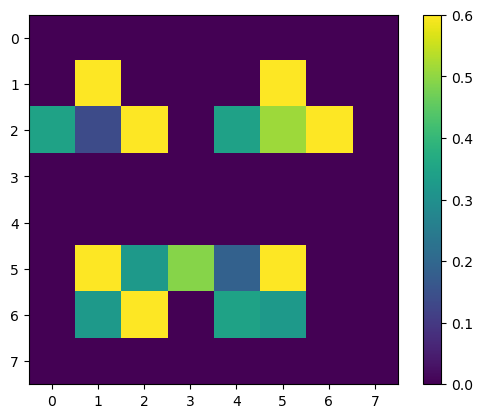

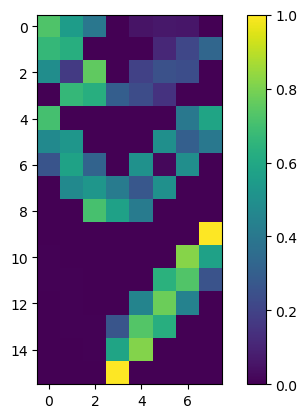

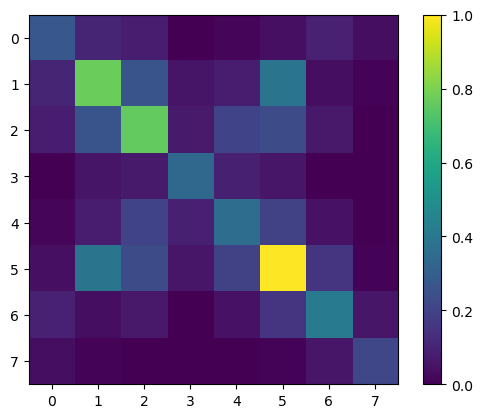

In [5]:
import matplotlib.pyplot as plt

plt.imshow(TS_P12, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.show()

plt.imshow(TS_P32, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.show()


plt.imshow(raman_table, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.show()

In [7]:
generateLabels_S12(0.5, 1.5, S12_Energy_at(b)[1])[0]

['1,-1', '1,0', '1,1', '2,2', '2,1', '2,0', '2,-1', '2,-2']